In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
from matplotlib import pyplot as plt 
import seaborn as sns
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = None
pd.options.display.max_columns = None
sns.set();

In [4]:
df = pd.read_csv("test.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Employee ID               14900 non-null  int64
 1   Age                       14900 non-null  int64
 2   Gender                    14900 non-null  str  
 3   Years at Company          14900 non-null  int64
 4   Job Role                  14900 non-null  str  
 5   Monthly Income            14900 non-null  int64
 6   Work-Life Balance         14900 non-null  str  
 7   Job Satisfaction          14900 non-null  str  
 8   Performance Rating        14900 non-null  str  
 9   Number of Promotions      14900 non-null  int64
 10  Overtime                  14900 non-null  str  
 11  Distance from Home        14900 non-null  int64
 12  Education Level           14900 non-null  str  
 13  Marital Status            14900 non-null  str  
 14  Number of Dependents      14900 non-null  int64
 

# Bivariate analysis

In [5]:
df.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,"14,900.00","14,900.00","14,900.00","14,900.00","14,900.00","14,900.00","14,900.00","14,900.00"
mean,"37,339.02",38.39,15.59,"7,287.31",0.83,49.93,1.66,55.60
std,"21,453.13",12.10,11.13,"2,156.74",1.00,28.70,1.55,25.35
min,5.00,18.00,1.00,"1,226.00",0.00,1.00,0.00,2.00
25%,"18,825.50",28.00,7.00,"5,633.75",0.00,25.00,0.00,36.00
50%,"37,433.00",38.00,13.00,"7,332.00",1.00,50.00,1.00,56.00
75%,"55,857.50",49.00,23.00,"8,852.00",2.00,75.00,3.00,75.00
max,"74,471.00",59.00,51.00,"15,063.00",4.00,99.00,6.00,127.00


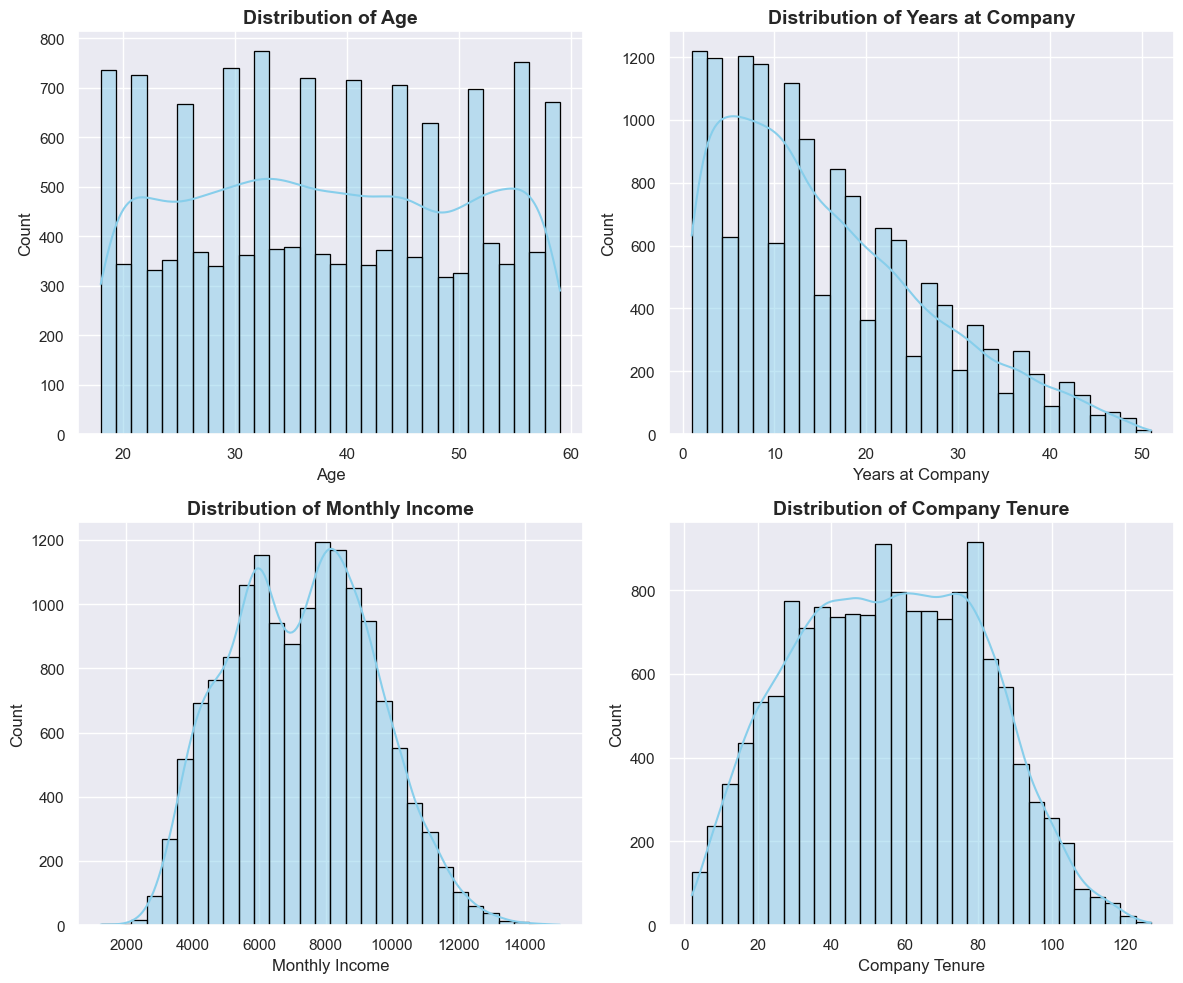

In [6]:
columns = ['Age', 'Years at Company', 'Monthly Income', 'Company Tenure']
plt.figure(figsize=(12,10))
for e, col in enumerate(columns):
    plt.subplot(2,2, e+1)
    sns.histplot(data=df, x=col, kde=True, bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

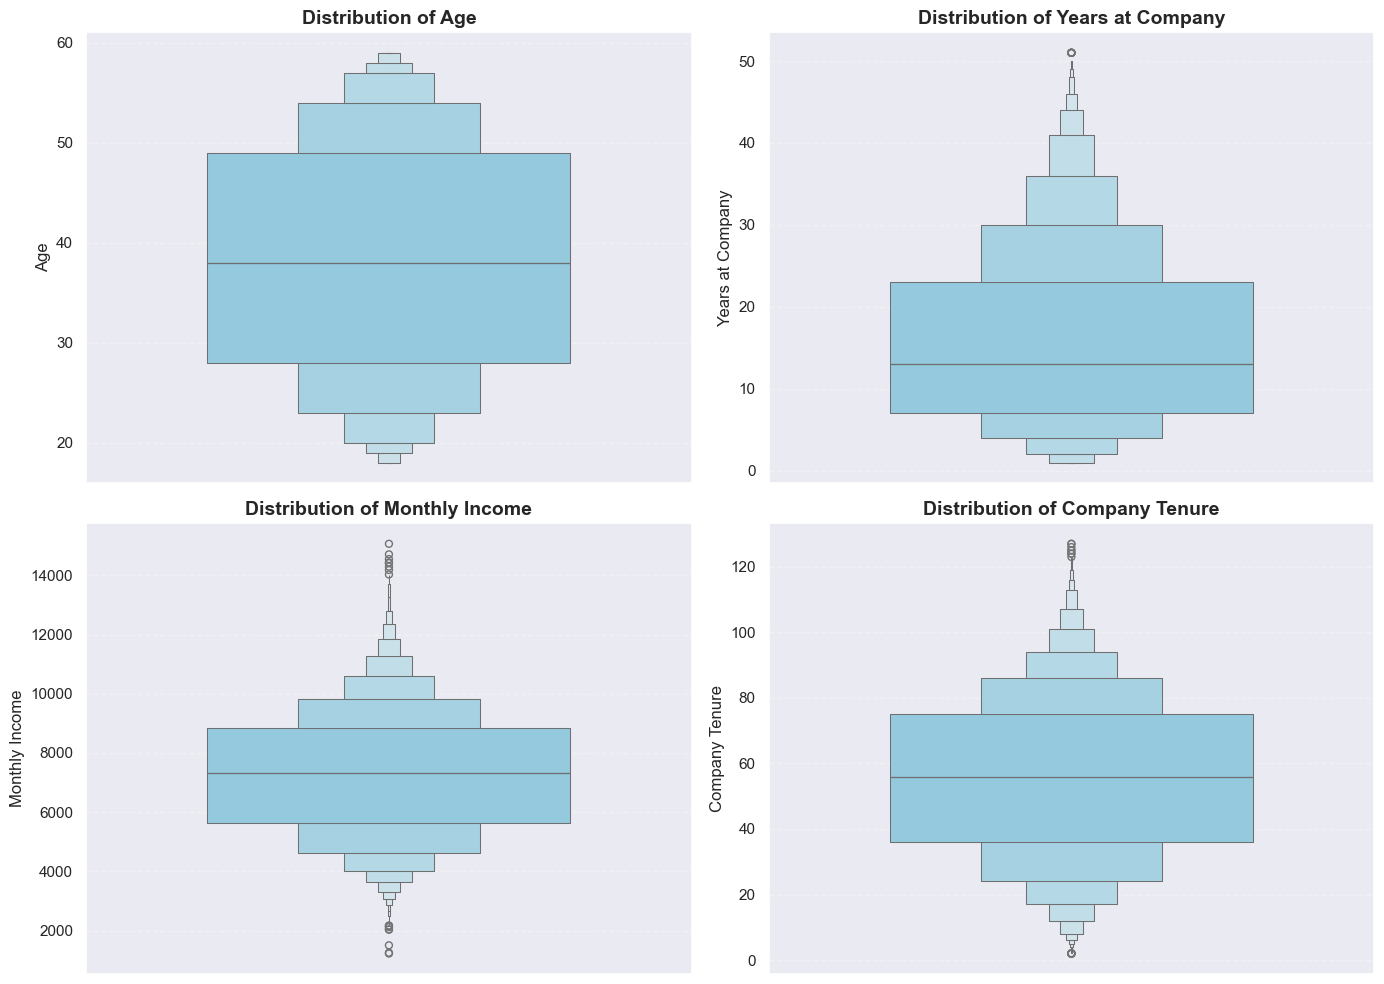

In [7]:
columns = ['Age', 'Years at Company', 'Monthly Income', 'Company Tenure']
plt.figure(figsize=(14, 10))

for e, col in enumerate(columns):
    plt.subplot(2, 2, e+1)
    sns.boxenplot(data=df, y=col, color='skyblue', width=0.6)
    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    plt.ylabel(col, fontsize=12)
    plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Employee ID               14900 non-null  int64
 1   Age                       14900 non-null  int64
 2   Gender                    14900 non-null  str  
 3   Years at Company          14900 non-null  int64
 4   Job Role                  14900 non-null  str  
 5   Monthly Income            14900 non-null  int64
 6   Work-Life Balance         14900 non-null  str  
 7   Job Satisfaction          14900 non-null  str  
 8   Performance Rating        14900 non-null  str  
 9   Number of Promotions      14900 non-null  int64
 10  Overtime                  14900 non-null  str  
 11  Distance from Home        14900 non-null  int64
 12  Education Level           14900 non-null  str  
 13  Marital Status            14900 non-null  str  
 14  Number of Dependents      14900 non-null  int64
 

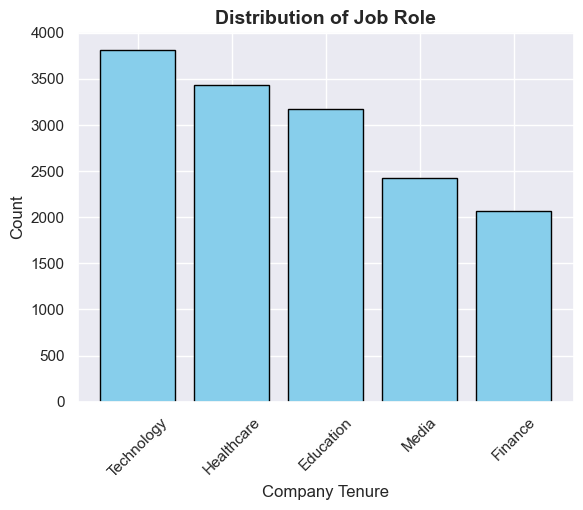

In [9]:
value_count = df['Job Role'].value_counts()
plt.bar(value_count.index, value_count.values, color='skyblue', edgecolor='black')
plt.title(f'Distribution of Job Role', fontsize=14, fontweight='bold')
plt.xlabel(col, fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tick_params(axis='x', rotation=45)

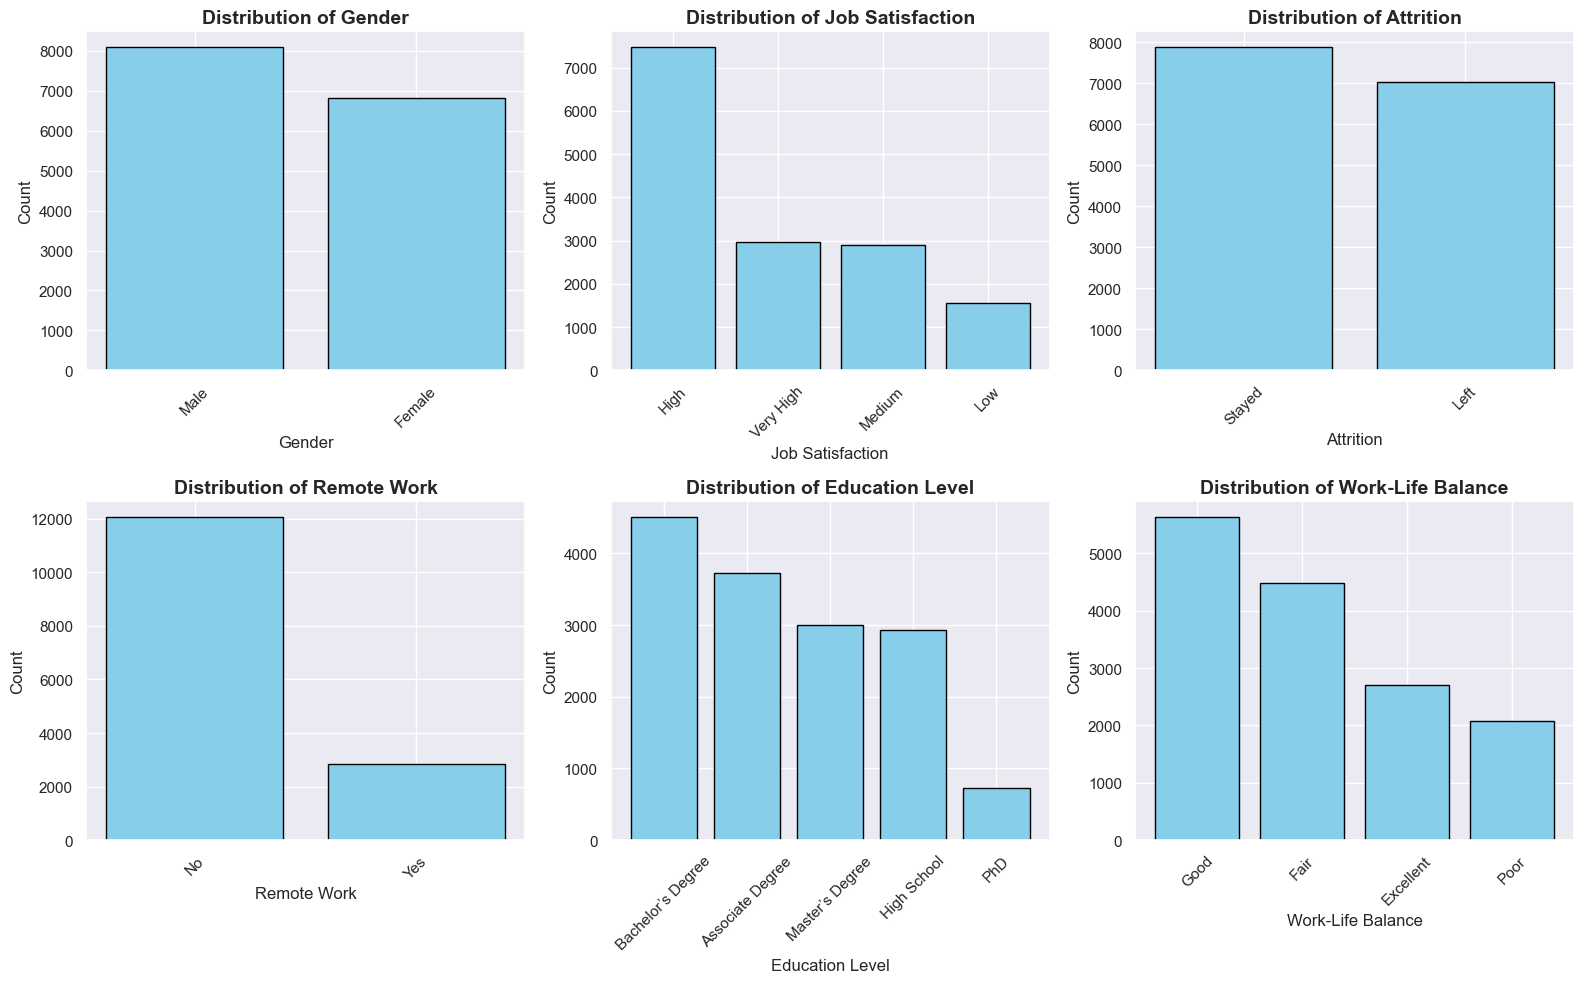

In [10]:
categorical_cols = ['Gender', 'Job Satisfaction', 'Attrition', 'Remote Work', 'Education Level', 'Work-Life Balance']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    axes[idx].bar(value_counts.index, value_counts.values, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=12)
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# bivariate analysis

## why people leave work

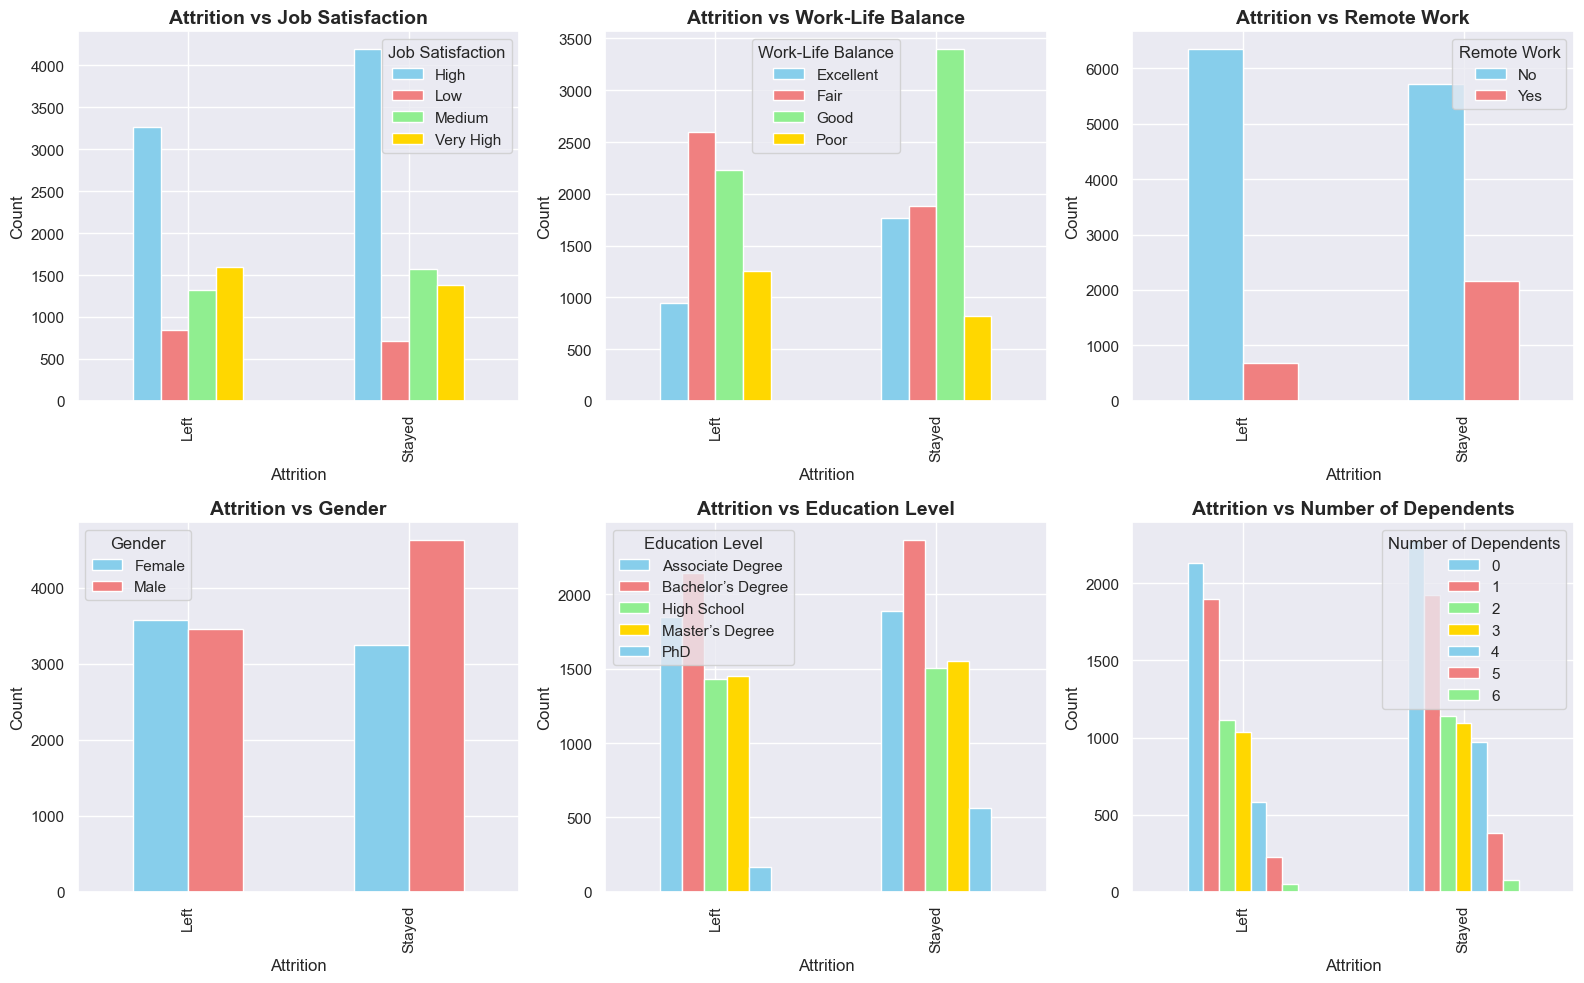

In [11]:
cols = ['Job Satisfaction', 'Work-Life Balance', 'Remote Work', 'Gender', 'Education Level', 'Number of Dependents']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(cols):
    crosstab = pd.crosstab(df['Attrition'], df[col])
    crosstab.plot(kind='bar', ax=axes[idx], color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
    axes[idx].set_title(f'Attrition vs {col}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Attrition', fontsize=12)
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].legend(title=col)

plt.tight_layout()
plt.show()


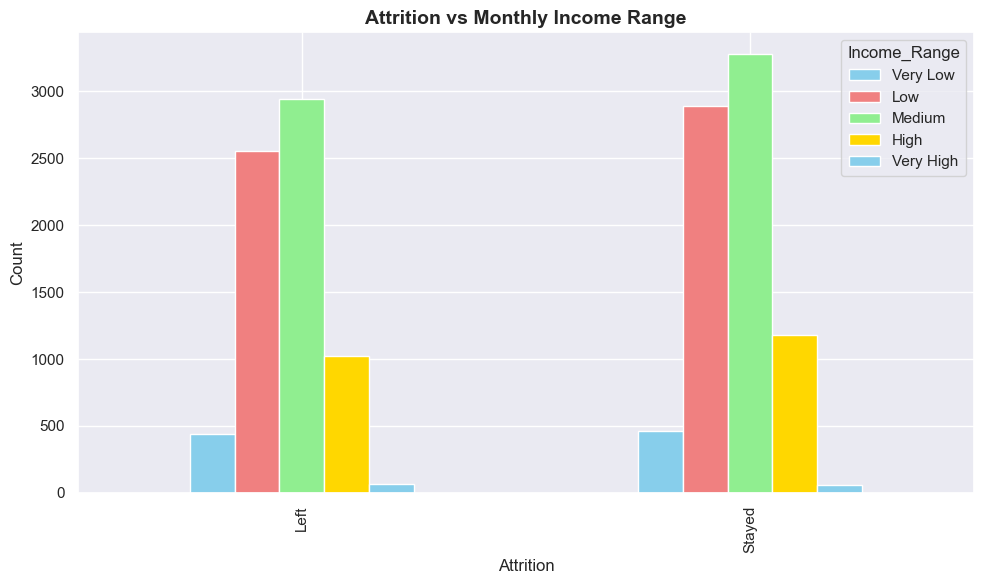

In [12]:
df['Income_Range'] = pd.cut(df['Monthly Income'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

crosstab = pd.crosstab(df['Attrition'], df['Income_Range'])
crosstab.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Attrition vs Monthly Income Range', fontsize=14, fontweight='bold')
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

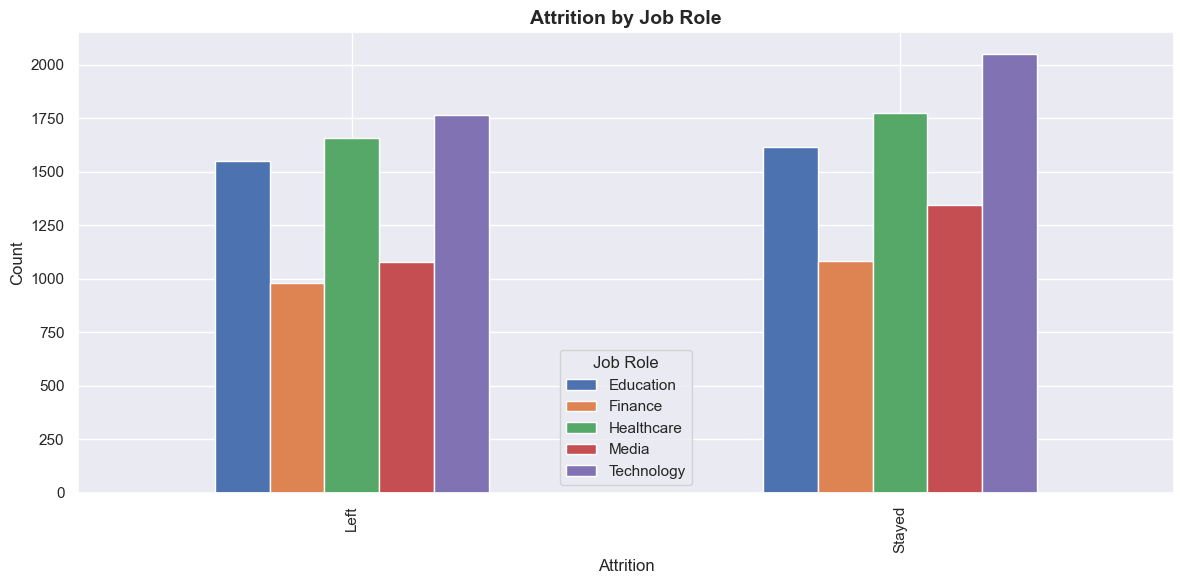

In [13]:
crosstab = pd.crosstab(df['Attrition'], df['Job Role'])
crosstab.plot(kind='bar', figsize=(12, 6))
plt.title('Attrition by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

#### Employees are more likely to stay when they have good work-life balance and remote work options. Employees with fair or poor work-life balance tend to leave the company. Job satisfaction alone does not prevent attrition - other factors like work environment and flexibility matter more.

## Job Role Stability by Years at Company

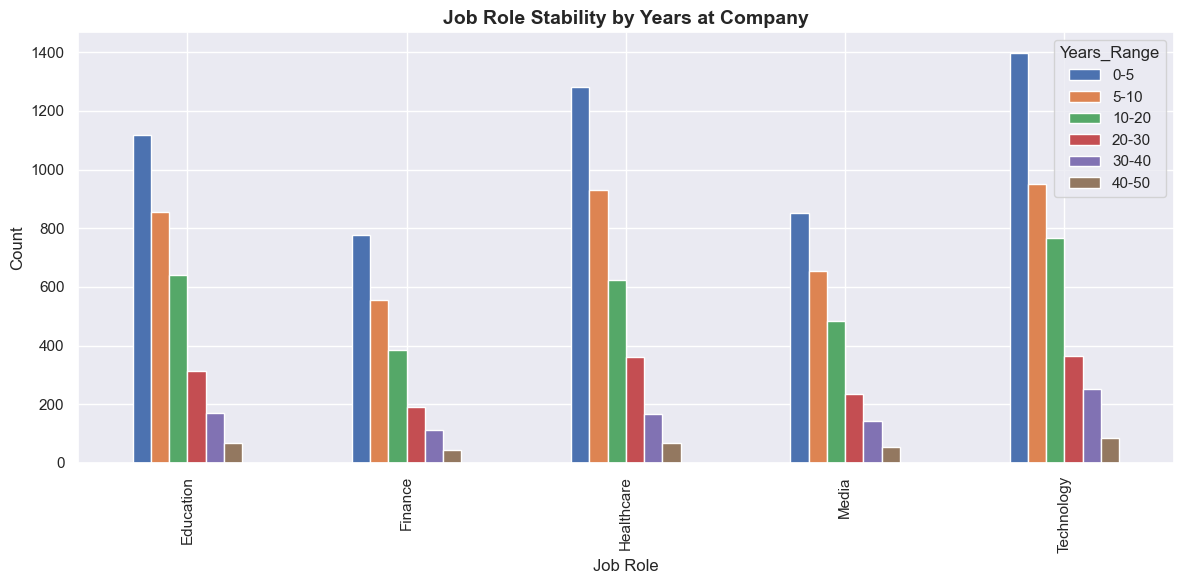

In [14]:
df['Years_Range'] = pd.cut(df['Years at Company'], bins=6, labels=['0-5', '5-10', '10-20', '20-30', '30-40', '40-50'])

crosstab = pd.crosstab(df['Job Role'], df['Years_Range'])
crosstab.plot(kind='bar', figsize=(12, 6))
plt.title('Job Role Stability by Years at Company', fontsize=14, fontweight='bold')
plt.xlabel('Job Role', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

## Job Role Stability by Years at Company

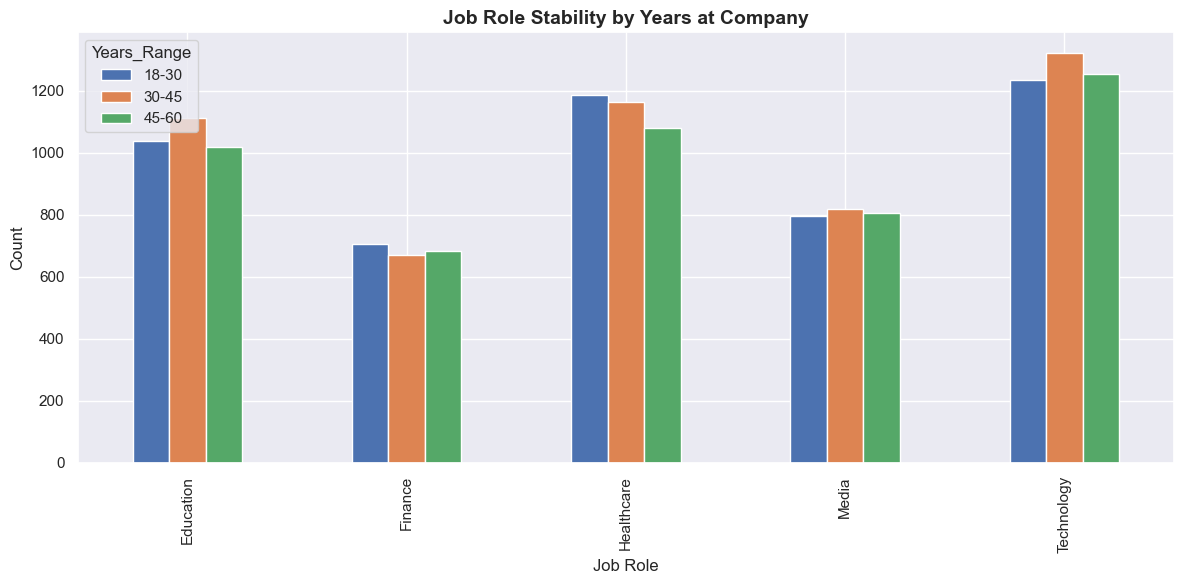

In [15]:
df['Years_Range'] = pd.cut(df['Age'], bins=3, labels=['18-30', '30-45', '45-60'])

crosstab = pd.crosstab(df['Job Role'], df['Years_Range'])
crosstab.plot(kind='bar', figsize=(12, 6))
plt.title('Job Role Stability by Years at Company', fontsize=14, fontweight='bold')
plt.xlabel('Job Role', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

## Job Role vs Monthly Income

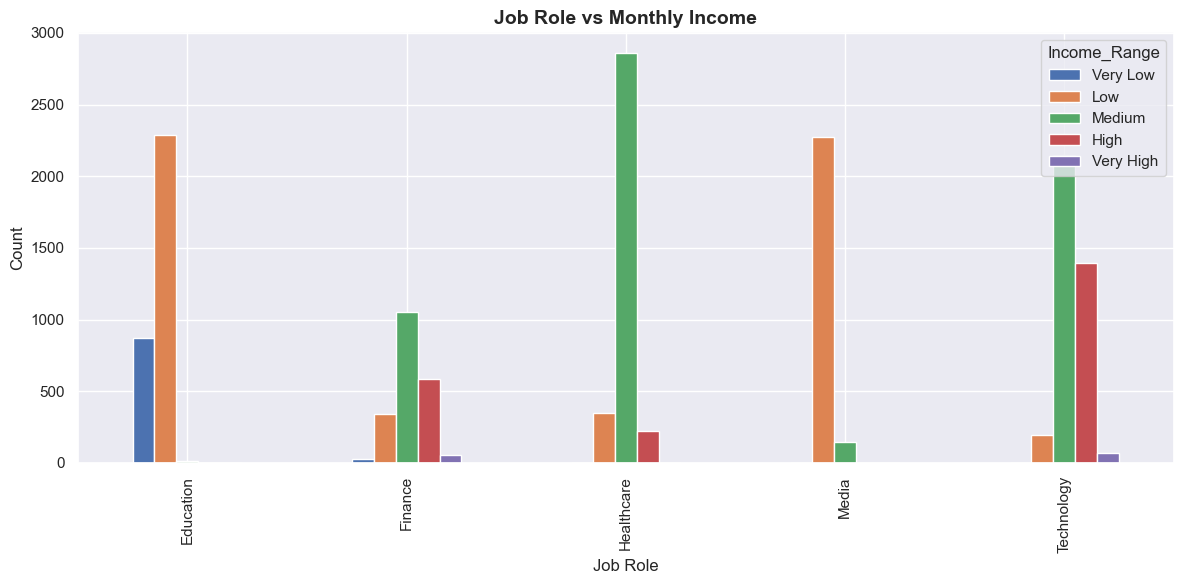

In [16]:
df['Income_Range'] = pd.cut(df['Monthly Income'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

crosstab = pd.crosstab(df['Job Role'], df['Income_Range'])
crosstab.plot(kind='bar', figsize=(12, 6))
plt.title('Job Role vs Monthly Income', fontsize=14, fontweight='bold')
plt.xlabel('Job Role', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

## Job Role vs Gender

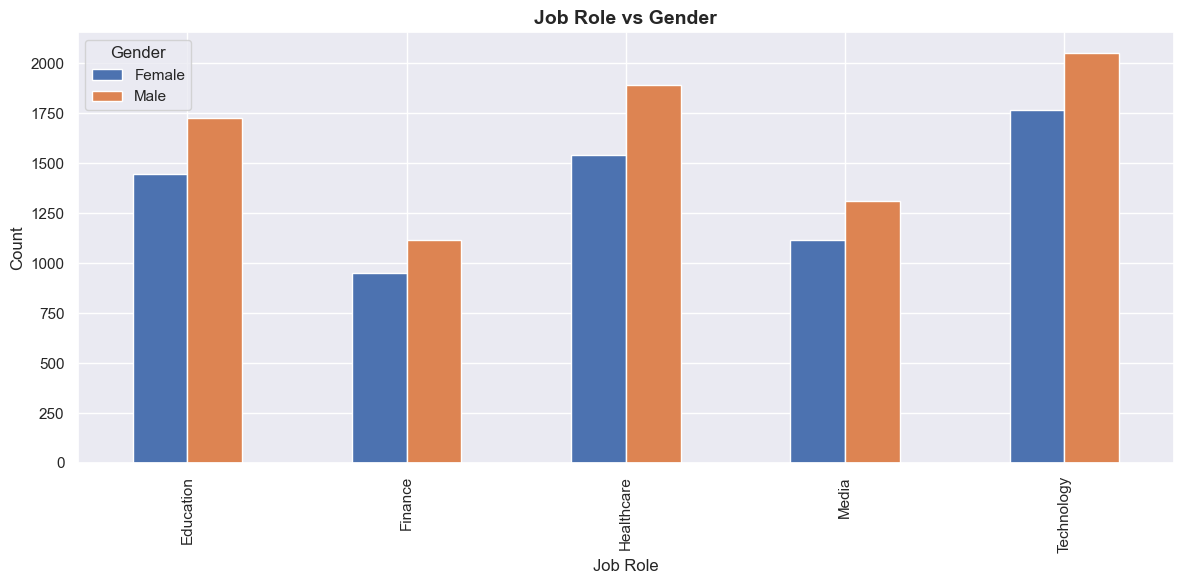

In [17]:
crosstab = pd.crosstab(df['Job Role'], df['Gender'])
crosstab.plot(kind='bar', figsize=(12, 6))
plt.title('Job Role vs Gender', fontsize=14, fontweight='bold')
plt.xlabel('Job Role', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

## Job Satisfaction vs Gender

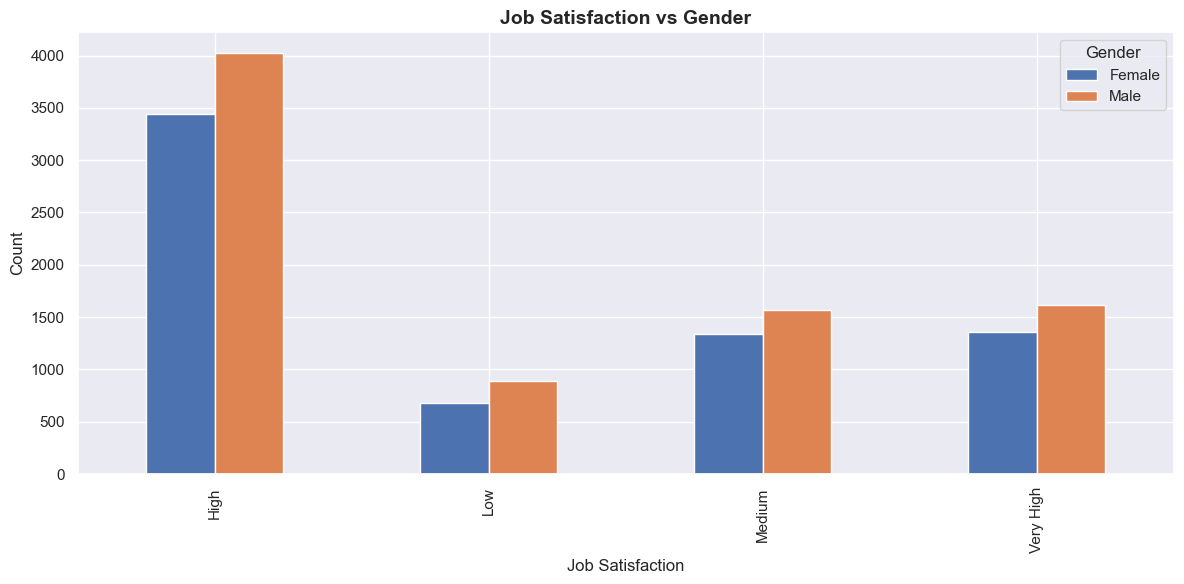

In [18]:
crosstab = pd.crosstab(df['Job Satisfaction'], df['Gender'])
crosstab.plot(kind='bar', figsize=(12, 6))
plt.title('Job Satisfaction vs Gender', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

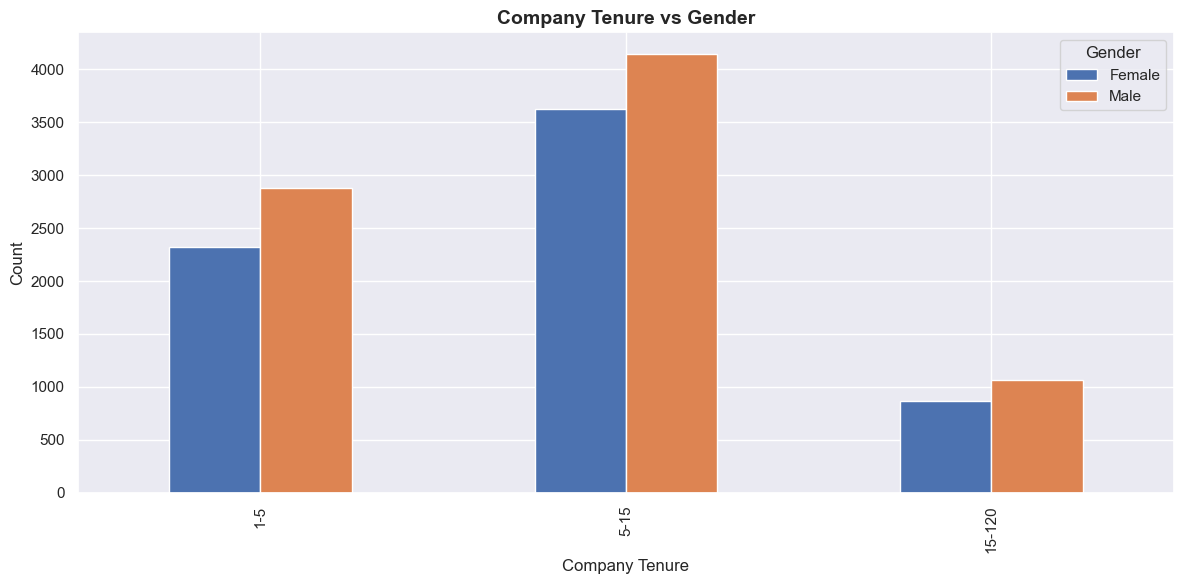

In [19]:
df['Years_Range'] = pd.cut(df['Company Tenure'], bins=3, labels=['1-5', '5-15', '15-120'])
crosstab = pd.crosstab(df['Years_Range'], df['Gender'])
crosstab.plot(kind='bar', figsize=(12, 6))
plt.title('Company Tenure vs Gender', fontsize=14, fontweight='bold')
plt.xlabel('Company Tenure', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

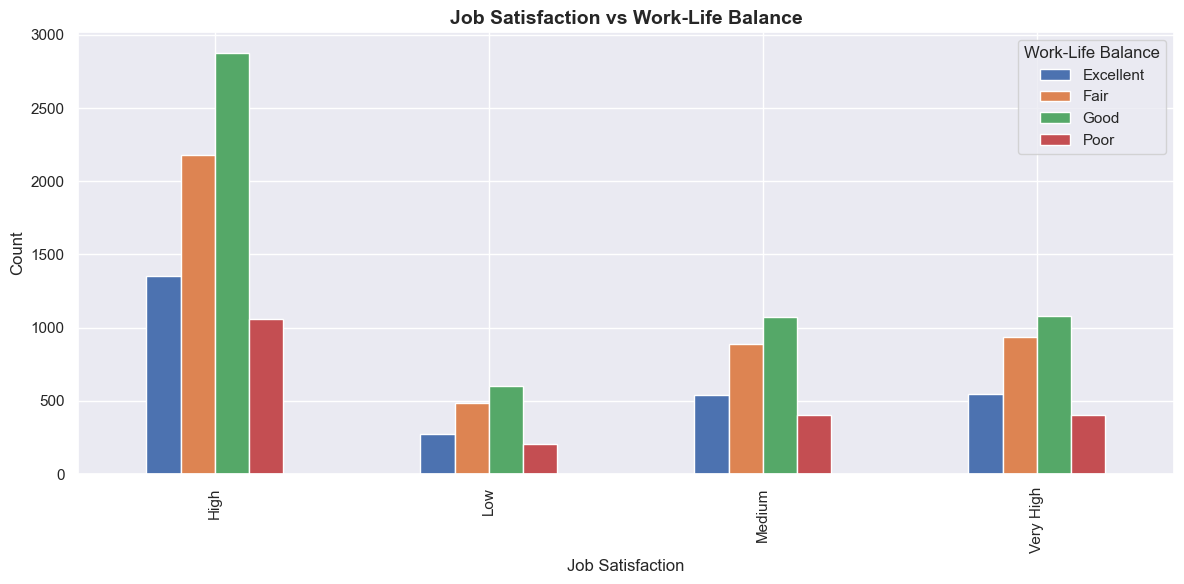

In [20]:
crosstab = pd.crosstab(df['Job Satisfaction'], df['Work-Life Balance'])
crosstab.plot(kind='bar', figsize=(12, 6))
plt.title('Job Satisfaction vs Work-Life Balance', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

## Correlation Analysis

<Axes: >

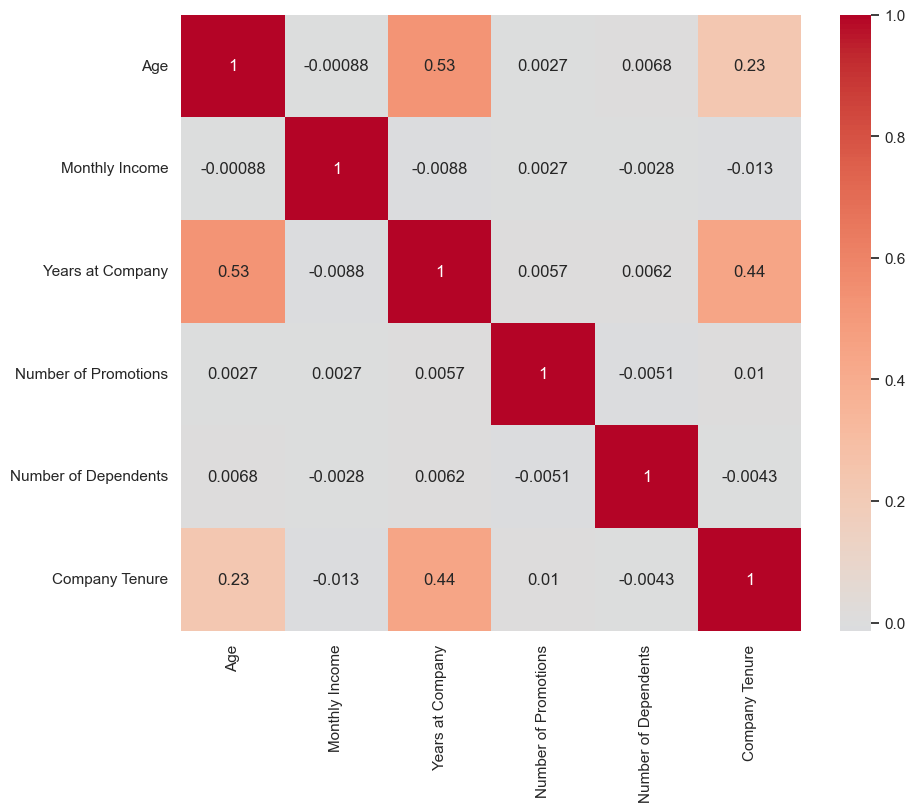

In [21]:
numeric_cols = ['Age', 'Monthly Income', 'Years at Company', 'Number of Promotions', 'Number of Dependents', 'Company Tenure']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)

# 📋 Correlation Analysis Summary

## Key Finding

All variables in this dataset have **VERY WEAK or NO correlations** with each other.

| Variable Pair | Correlation | Interpretation |
|---------------|-------------|-----------------|
| Age ↔ Years at Company | 0.53 | **Only meaningful correlation** |
| Years at Company ↔ Company Tenure | 0.44 | Moderate |
| Age ↔ Company Tenure | 0.23 | Weak |
| **All Other Pairs** | **~0.00 to 0.01** | **NO CORRELATION** |

## Bottom Line

❌ **Age does NOT affect salary**
❌ **Tenure does NOT affect salary**
❌ **Promotions are RANDOM**
❌ **Income is INDEPENDENT of experience**

**Implication:** Employee compensation and advancement have **no clear relationship** with their experience, age, or time at company. This could be a major cause of attrition.

## Key Insight

The lack of correlation between tenure/experience and compensation suggests:
- No clear career progression path
- Salary not tied to loyalty or experience
- Promotions appear arbitrary or merit-based without clear metrics
- Employees may feel undervalued regardless of tenure

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Employee ID               14900 non-null  int64   
 1   Age                       14900 non-null  int64   
 2   Gender                    14900 non-null  str     
 3   Years at Company          14900 non-null  int64   
 4   Job Role                  14900 non-null  str     
 5   Monthly Income            14900 non-null  int64   
 6   Work-Life Balance         14900 non-null  str     
 7   Job Satisfaction          14900 non-null  str     
 8   Performance Rating        14900 non-null  str     
 9   Number of Promotions      14900 non-null  int64   
 10  Overtime                  14900 non-null  str     
 11  Distance from Home        14900 non-null  int64   
 12  Education Level           14900 non-null  str     
 13  Marital Status            14900 non-null  str     
 14  N

In [23]:
attrition_rate = (df['Attrition'] == 'Stayed').sum() / len(df) * 100
print(attrition_rate)

52.80536912751678


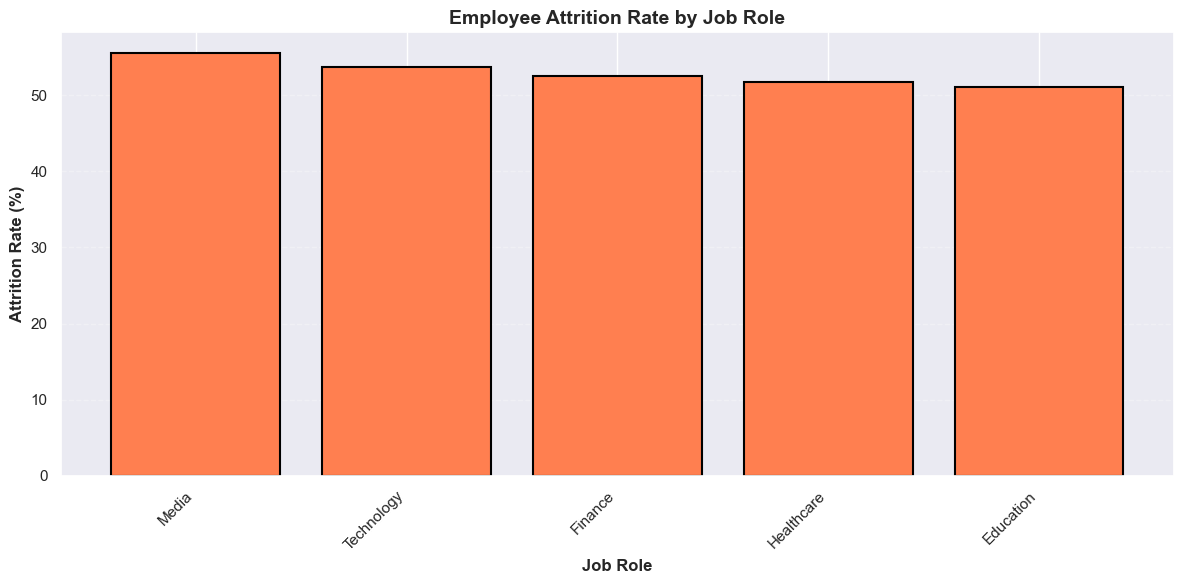

In [24]:
attrition_by_role = df.groupby('Job Role')['Attrition'].apply(
    lambda x: (x == 'Stayed').sum() / len(x) * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(attrition_by_role.index, attrition_by_role.values, 
        color='coral', edgecolor='black', linewidth=1.5)
plt.xlabel('Job Role', fontsize=12, fontweight='bold')
plt.ylabel('Attrition Rate (%)', fontsize=12, fontweight='bold')
plt.title('Employee Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


ATTRITION RATE BY SALARY LEVEL


/var/folders/81/95fj7lrn2sl42xf3x5dm8ks40000gn/T/ipykernel_4094/1877734882.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


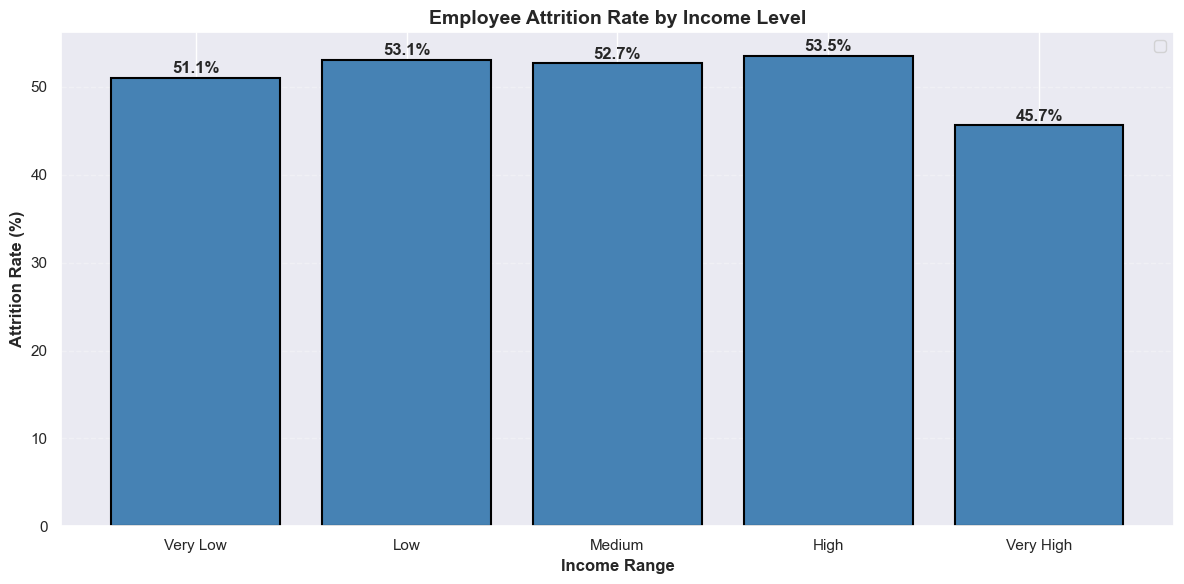

In [ ]:
print("\n" + "=" * 70)
print("ATTRITION RATE BY SALARY LEVEL")
print("=" * 70)

df['Income_Range'] = pd.cut(df['Monthly Income'], 
                             bins=5,  # 5 groups
                             labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

attrition_by_income = df.groupby('Income_Range')['Attrition'].apply(
    lambda x: (x == 'Stayed').sum() / len(x) * 100  # CORRECT: 'Yes'
)

plt.figure(figsize=(12, 6))
plt.bar(attrition_by_income.index, attrition_by_income.values,
        color='steelblue', edgecolor='black', linewidth=1.5)

for i, v in enumerate(attrition_by_income.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.xlabel('Income Range', fontsize=12, fontweight='bold')
plt.ylabel('Attrition Rate (%)', fontsize=12, fontweight='bold')
plt.title('Employee Attrition Rate by Income Level', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("=" * 70)


ATTRITION RATE BY WORK-LIFE BALANCE
Work-Life Balance
Excellent   64.98
Good        60.37
Fair        42.07
Poor        39.54
Name: Attrition, dtype: float64



/var/folders/81/95fj7lrn2sl42xf3x5dm8ks40000gn/T/ipykernel_4094/2725280977.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


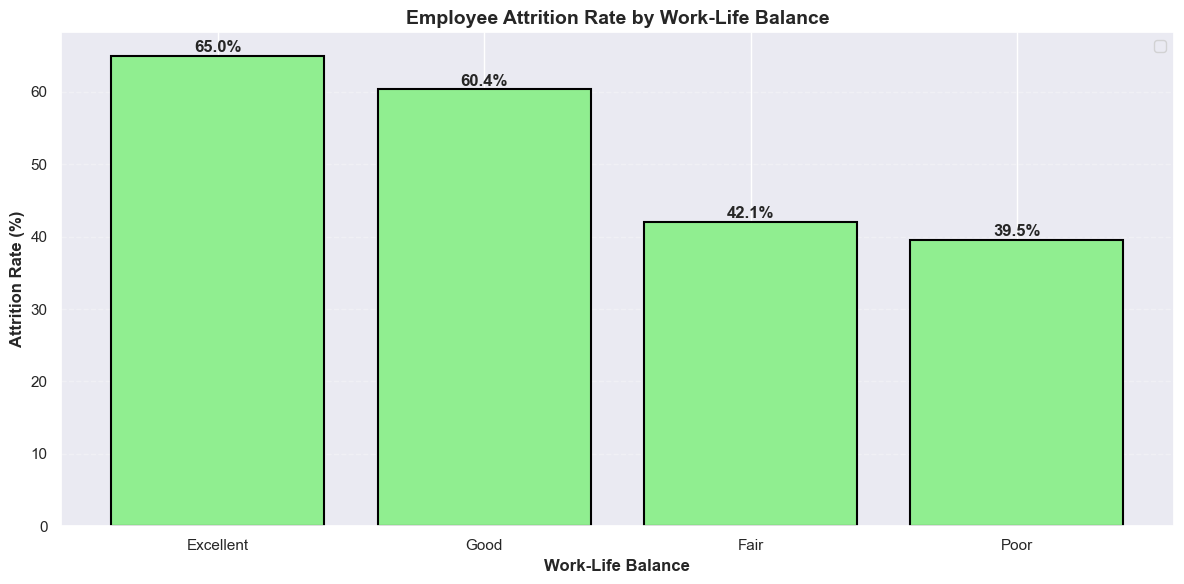

In [31]:
print("\n" + "=" * 70)
print("ATTRITION RATE BY WORK-LIFE BALANCE")
print("=" * 70)

attrition_by_balance = df.groupby('Work-Life Balance')['Attrition'].apply(
    lambda x: (x == 'Stayed').sum() / len(x) * 100
).sort_values(ascending=False)

print(attrition_by_balance)
print()

plt.figure(figsize=(12, 6))
plt.bar(attrition_by_balance.index, attrition_by_balance.values,
        color='lightgreen', edgecolor='black', linewidth=1.5)

for i, v in enumerate(attrition_by_balance.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.xlabel('Work-Life Balance', fontsize=12, fontweight='bold')
plt.ylabel('Attrition Rate (%)', fontsize=12, fontweight='bold')
plt.title('Employee Attrition Rate by Work-Life Balance', fontsize=14, fontweight='bold')
# plt.axhline(y=overall, color='red', linestyle='--', linewidth=2, label=f'Overall: {overall:.1f}%')
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("=" * 70)